In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
#Import Libraries
import pandas as pd
import numpy as np

In [8]:
#Reading the dataset
dataset = pd.read_csv("/content/Bikesharing.csv")

In [9]:
dataset

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


In [10]:
dataset.shape

(730, 16)

In [11]:
dataset.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [12]:
dataset.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [14]:
#Assigning string values to different seasons instead of numeric values

# 1= spring
dataset.loc[dataset['season']==1,'season']='spring'

#2=summer
dataset.loc[dataset['season']==2,'season']='summer'

#3=fall
dataset.loc[dataset['season']==3,'season']='fall'

#4=winter
dataset.loc[dataset['season']==4,'season']='winter'

In [15]:
dataset['season'].astype('category').value_counts()

,count
season,
fall,188
summer,184
spring,180
winter,178


In [16]:
# 0=2018, 1=2019 : year
dataset['yr'].astype('category').value_counts()

,count
yr,
0,365
1,365


In [17]:
def object_map_mnths(x):
  return x.map({1: 'Jan', 2: 'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sept', 10:'oct', 11:'Nov', 12:'Dec'})

In [18]:
dataset[['mnth']] = dataset[['mnth']].apply(object_map_mnths)

In [19]:
dataset['mnth'].astype('category').value_counts()

,count
mnth,
Aug,62
Dec,62
Jul,62
Jan,62
oct,62
May,62
Mar,62
Apr,60
Nov,60


In [20]:
def str_map_weekday(x):
  return x.map({0: 'Sunday', 1: 'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday', 5:'Friday', 6:'Saturday'})

In [21]:
dataset[['weekday']]=dataset[['weekday']].apply(str_map_weekday)

In [22]:
dataset['weekday'].astype('category').value_counts()

,count
weekday,
Monday,105
Saturday,105
Sunday,105
Friday,104
Thursday,104
Tuesday,104
Wednesday,103


In [23]:
dataset['workingday'].astype('category').value_counts()

,count
workingday,
1,499
0,231


In [24]:
dataset['holiday'].astype('category').value_counts()

,count
holiday,
0,709
1,21


In [25]:
# 1 = clear, few clouds, partily cloudly
dataset.loc[(dataset['weathersit'] == 1), 'weathersit'] = 'A'

# 2 = Mist, cloudly
dataset.loc[(dataset['weathersit'] == 2), 'weathersit'] = 'B'

# 3 = Heavy rain, light snow
dataset.loc[(dataset['weathersit'] == 3), 'weathersit'] = 'C'


In [26]:
dataset['weathersit'].astype('category').value_counts()

,count
weathersit,
A,463
B,246
C,21


In [27]:
# Importing libs
import matplotlib.pyplot as plt
import seaborn as sns

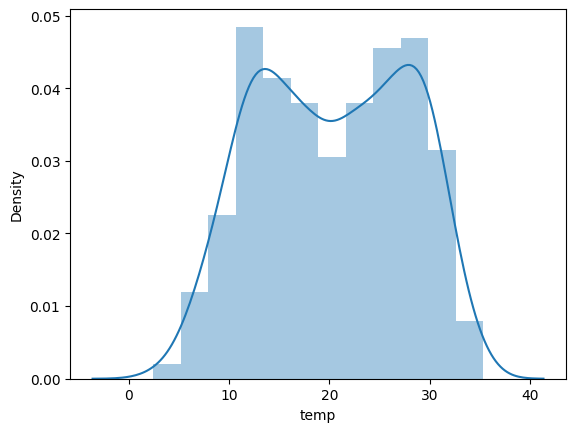

In [28]:
# Temperature
sns.distplot(dataset['temp'])
plt.show()

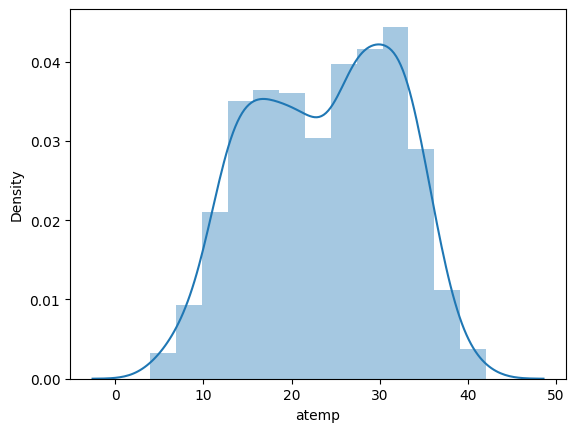

In [29]:
# Actual Temperature
sns.distplot(dataset['atemp'])
plt.show()

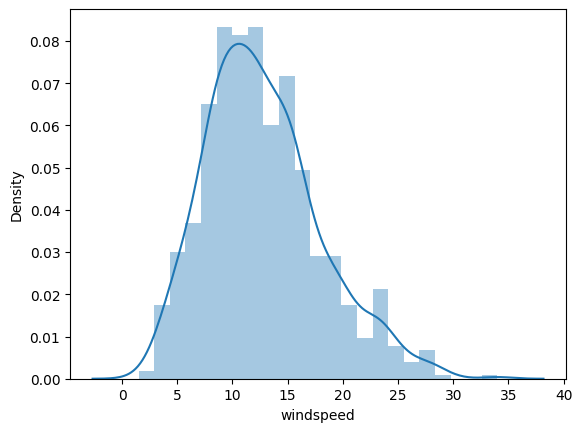

In [30]:
# wind speed

sns.distplot(dataset['windspeed'])
plt.show()

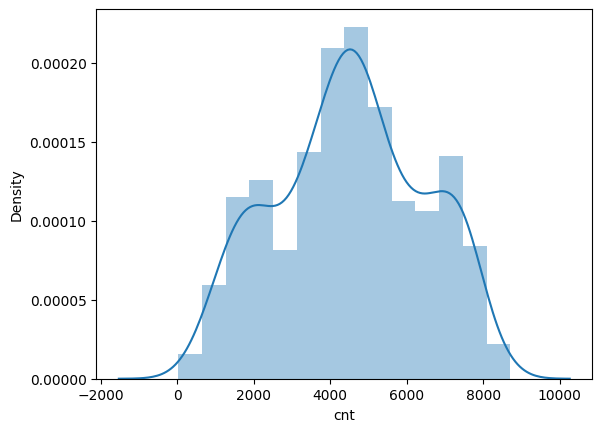

In [31]:
# Target variable: count of total rental bikes including both casual and registered

sns.distplot(dataset['cnt'])
plt.show()

In [32]:
# converting date to datetime format
dataset['dteday'] = dataset['dteday'].astype('datetime64[ns]')

In [33]:
dataset_categorial = dataset.select_dtypes(exclude=['float64', 'datetime64', 'int64'])

In [34]:
dataset_categorial.columns

Index(['season', 'mnth', 'weekday', 'weathersit'], dtype='object')

In [35]:
dataset_categorial

,season,mnth,weekday,weathersit
0,spring,Jan,Saturday,B
1,spring,Jan,Sunday,B
2,spring,Jan,Monday,A
3,spring,Jan,Tuesday,A
4,spring,Jan,Wednesday,A
...,...,...,...,...
725,spring,Dec,Thursday,B
726,spring,Dec,Friday,B
727,spring,Dec,Saturday,B
728,spring,Dec,Sunday,A


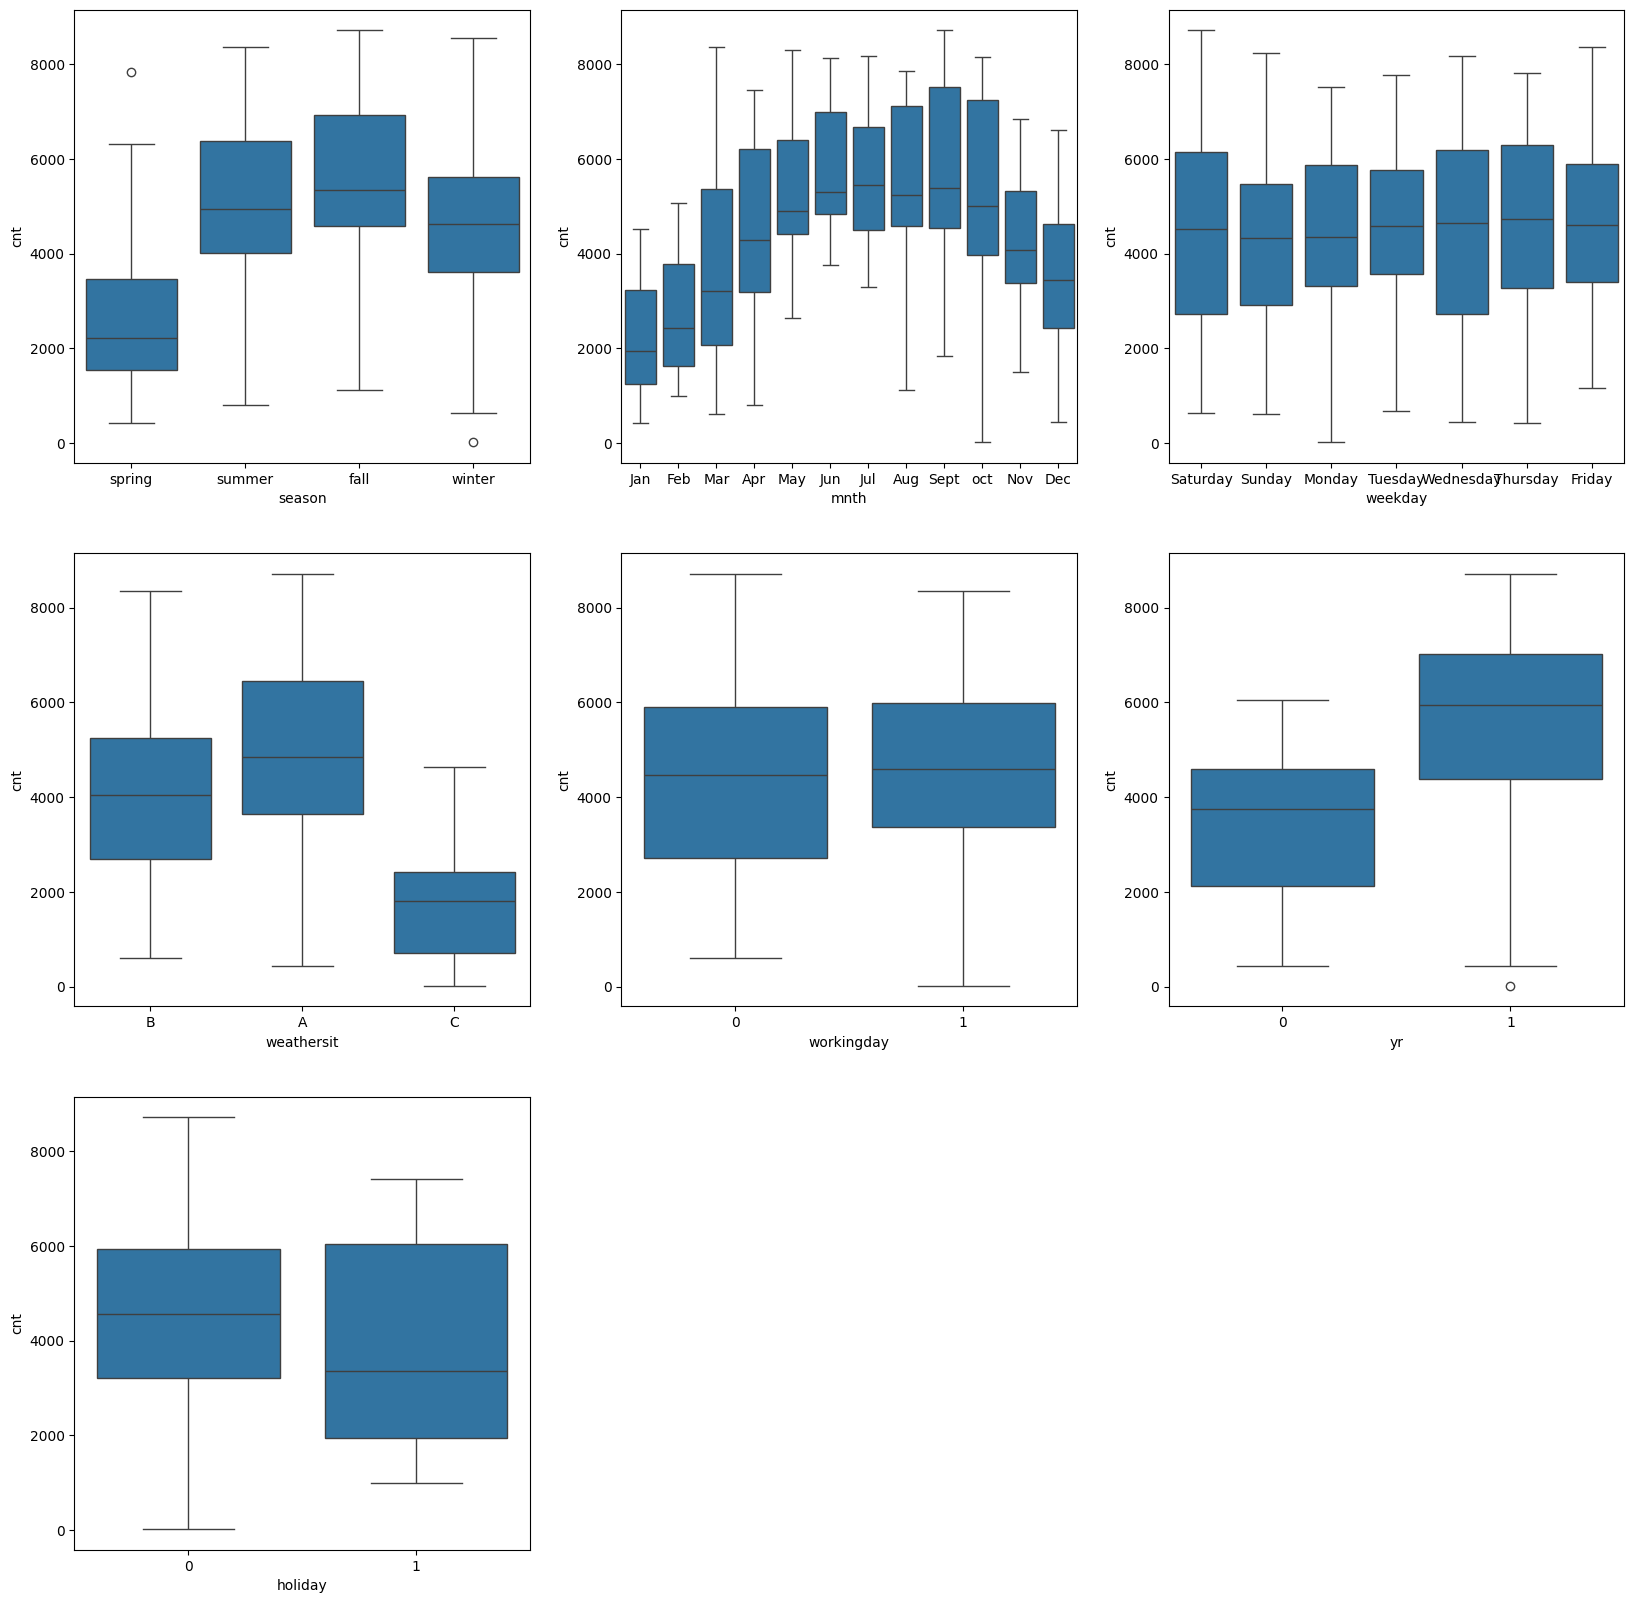

In [36]:
plt.figure(figsize=(20,20))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'cnt', data = dataset)
plt.subplot(3,3,2)
sns.boxplot(x = 'mnth', y = 'cnt', data = dataset)
plt.subplot(3,3,3)
sns.boxplot(x = 'weekday', y = 'cnt', data = dataset)
plt.subplot(3,3,4)
sns.boxplot(x = 'weathersit', y = 'cnt', data = dataset)
plt.subplot(3,3,5)
sns.boxplot(x = 'workingday', y = 'cnt', data = dataset)
plt.subplot(3,3,6)
sns.boxplot(x = 'yr', y = 'cnt', data = dataset)
plt.subplot(3,3,7)
sns.boxplot(x = 'holiday', y = 'cnt', data = dataset)
plt.show()

In [37]:
intVarlist = ["casual", "registered", "cnt"]

for var in intVarlist:
  dataset[var] = dataset[var].astype("float")

In [38]:
dataset_numeric = dataset.select_dtypes(include=['float64'])
dataset_numeric.head()

,temp,atemp,hum,windspeed,casual,registered,cnt
0,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


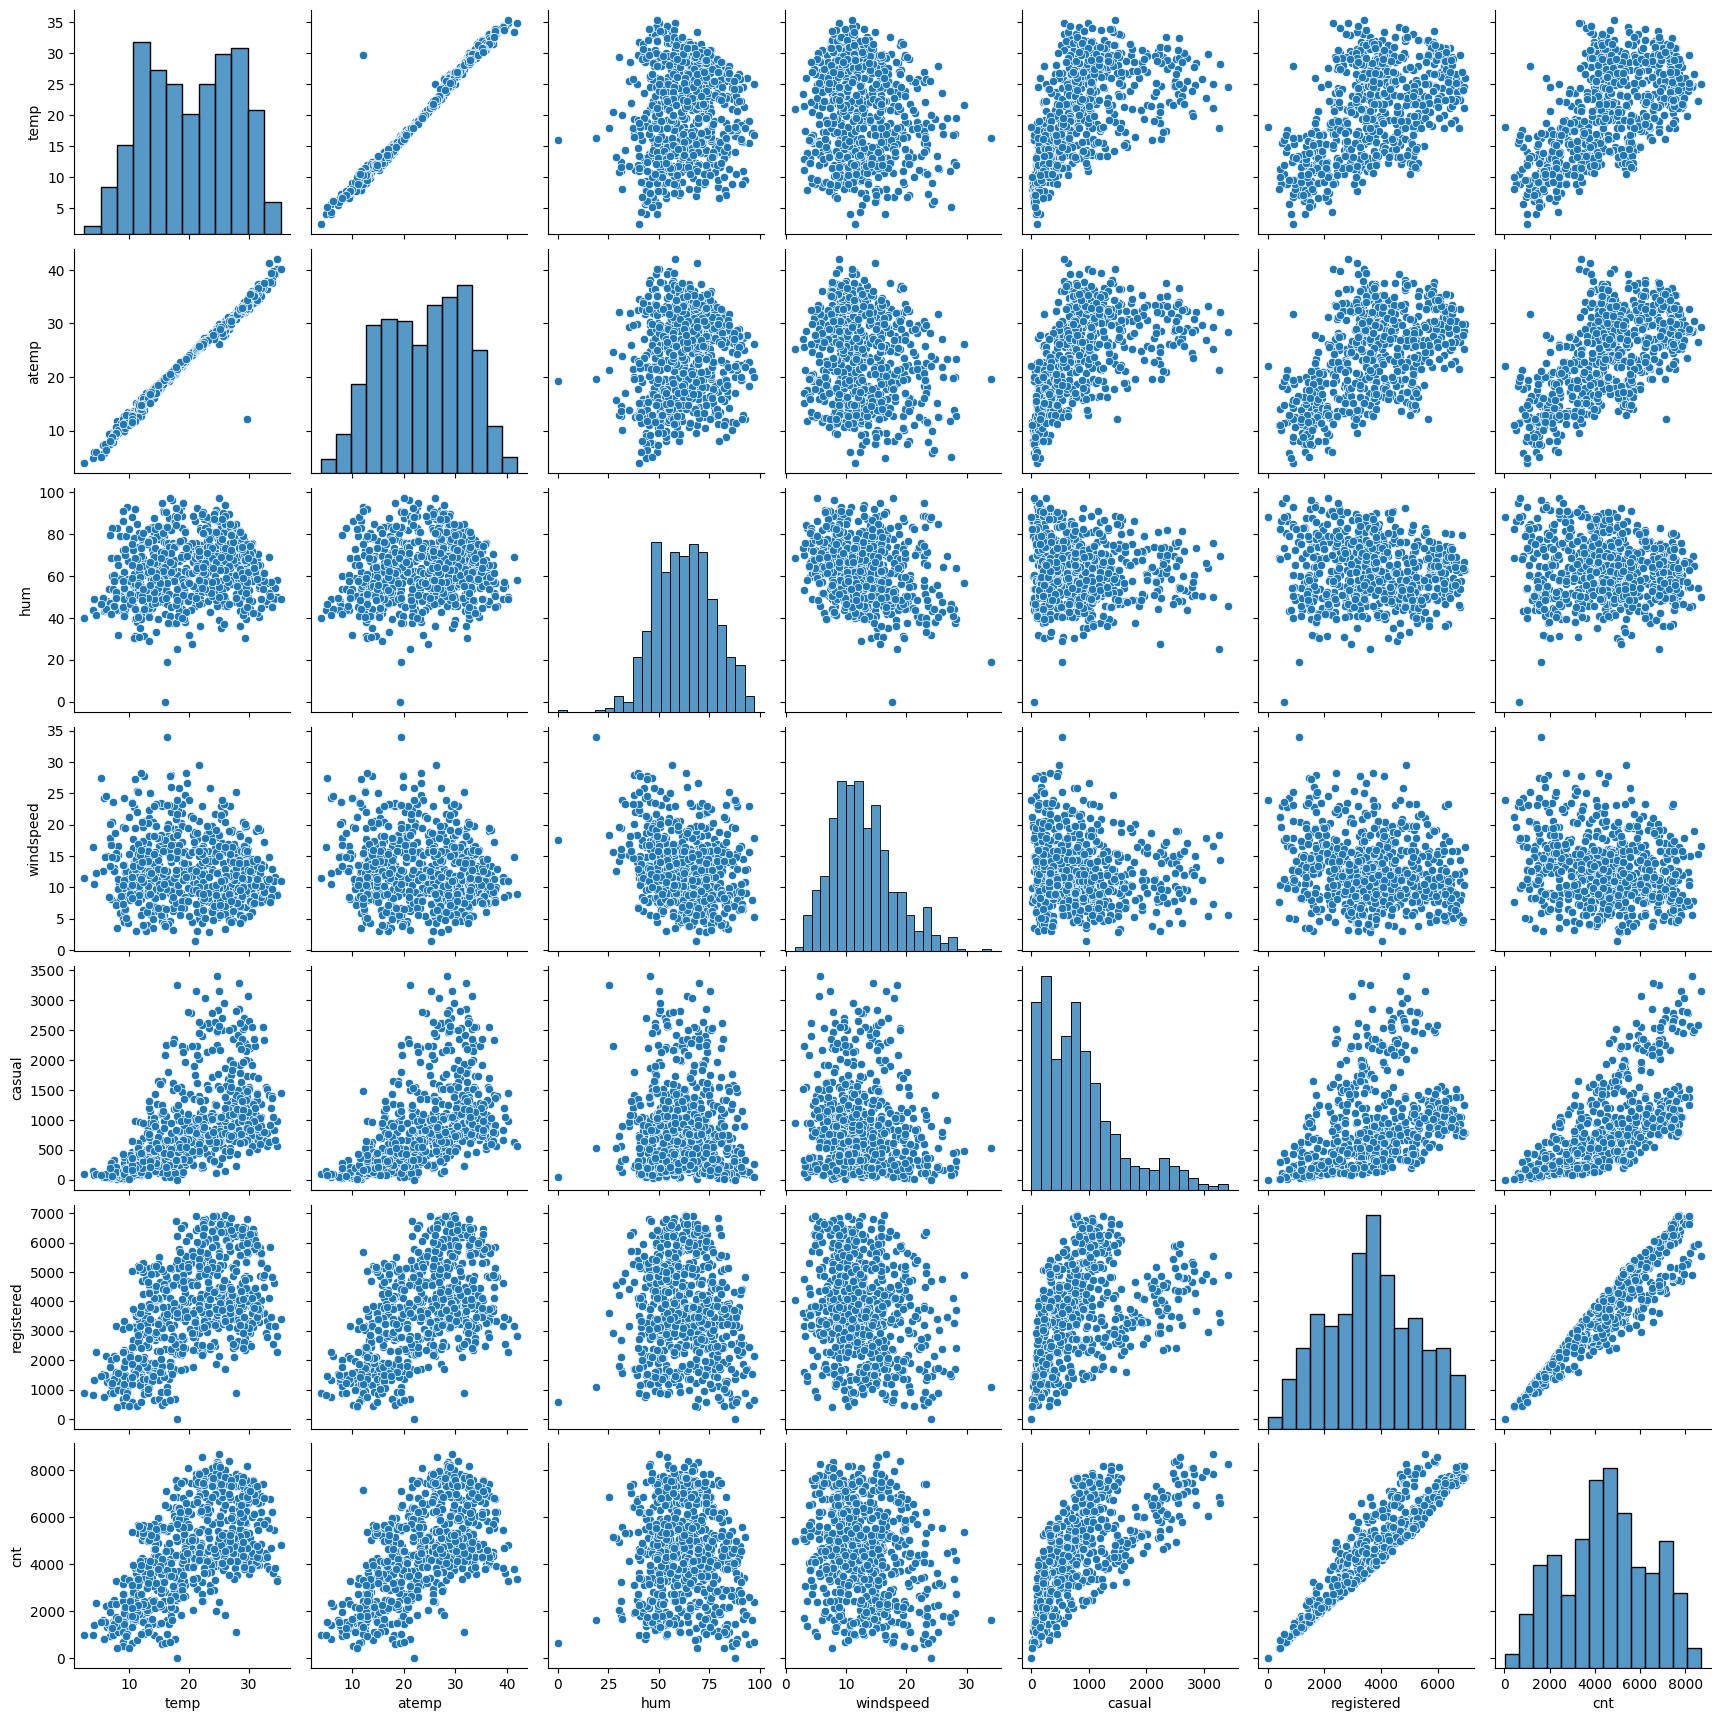

In [39]:
sns.pairplot(dataset_numeric)
plt.show()

In [40]:
cor = dataset_numeric.corr()
cor

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991696,0.128565,-0.158186,0.542731,0.539436,0.627044
atemp,0.991696,1.000000,0.141512,-0.183876,0.543362,0.543678,0.630685
hum,0.128565,0.141512,1.000000,-0.248506,-0.075211,-0.089212,-0.098543
windspeed,-0.158186,-0.183876,-0.248506,1.000000,-0.167995,-0.217914,-0.235132
casual,0.542731,0.543362,-0.075211,-0.167995,1.000000,0.394137,0.672123
registered,0.539436,0.543678,-0.089212,-0.217914,0.394137,1.000000,0.945411
cnt,0.627044,0.630685,-0.098543,-0.235132,0.672123,0.945411,1.000000


<Axes: >

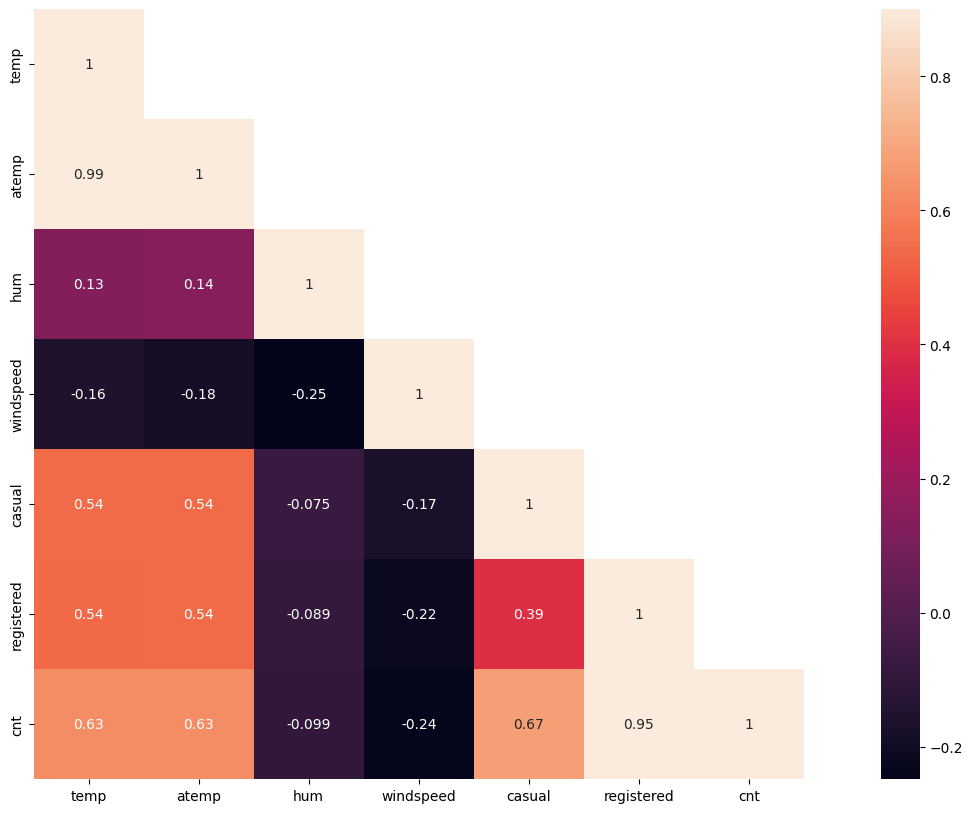

In [41]:
# heatmap
mask = np.array(cor)
mask[np.tril_indices_from(mask)]=False
fig,ax=plt.subplots()
fig.set_size_inches(20,10)
sns.heatmap(cor,mask=mask,vmax=0.9,square=True,annot=True)

In [42]:
# Removing atemp as it is highly corealed with temp
dataset.drop('atemp', axis=1, inplace=True)

In [43]:
dataset

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,spring,0,Jan,0,Saturday,0,B,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,spring,0,Jan,0,Sunday,0,B,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,spring,0,Jan,0,Monday,1,A,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,spring,0,Jan,0,Tuesday,1,A,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,spring,0,Jan,0,Wednesday,1,A,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,spring,1,Dec,0,Thursday,1,B,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,2019-12-28,spring,1,Dec,0,Friday,1,B,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,2019-12-29,spring,1,Dec,0,Saturday,0,B,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,2019-12-30,spring,1,Dec,0,Sunday,0,A,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


**DATA PREPARATION**

In [44]:
dataset_categorial = dataset.select_dtypes(include=['object'])

In [45]:
dataset_categorial.head()

,season,mnth,weekday,weathersit
0,spring,Jan,Saturday,B
1,spring,Jan,Sunday,B
2,spring,Jan,Monday,A
3,spring,Jan,Tuesday,A
4,spring,Jan,Wednesday,A


In [46]:
dataset_dummies = pd.get_dummies(dataset_categorial, drop_first=True)
dataset_dummies.head()

,season_spring,season_summer,season_winter,mnth_Aug,mnth_Dec,mnth_Feb,mnth_Jan,mnth_Jul,mnth_Jun,mnth_Mar,...,mnth_Sept,mnth_oct,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_B,weathersit_C
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [47]:
dataset = dataset.drop(list(dataset_categorial.columns), axis=1, errors='ignore')
dataset

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,1,0,1,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,2019-12-28,1,0,1,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,2019-12-29,1,0,0,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,2019-12-30,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


In [48]:
dataset = pd.concat([dataset, dataset_dummies], axis=1)

In [49]:
dataset

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,...,mnth_Sept,mnth_oct,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_B,weathersit_C
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,...,False,False,False,True,False,False,False,False,True,False
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,...,False,False,False,False,True,False,False,False,True,False
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,...,False,False,True,False,False,False,False,False,False,False
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,...,False,False,False,False,False,False,True,False,False,False
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,1,0,1,10.420847,65.2917,23.458911,247.0,1867.0,...,False,False,False,False,False,True,False,False,True,False
726,727,2019-12-28,1,0,1,10.386653,59.0000,10.416557,644.0,2451.0,...,False,False,False,False,False,False,False,False,True,False
727,728,2019-12-29,1,0,0,10.386653,75.2917,8.333661,159.0,1182.0,...,False,False,False,True,False,False,False,False,True,False
728,729,2019-12-30,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,...,False,False,False,False,True,False,False,False,False,False


In [50]:
dataset = dataset.drop(['instant', 'dteday'], axis=1, inplace=False)
dataset.head()

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,season_spring,...,mnth_Sept,mnth_oct,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_B,weathersit_C
0,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0,True,...,False,False,False,True,False,False,False,False,True,False
1,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0,True,...,False,False,False,False,True,False,False,False,True,False
2,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0,True,...,False,False,True,False,False,False,False,False,False,False
3,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0,True,...,False,False,False,False,False,False,True,False,False,False
4,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0,True,...,False,False,False,False,False,False,False,True,False,False


**Model Building and Evaluation**

In [51]:
#import libraries
from sklearn import linear_model
from sklearn.linear_model import LinearRegression

In [52]:
from sklearn.model_selection import train_test_split
np.random.seed(0)
df_train,df_test = train_test_split(dataset, train_size=0.7, test_size=0.3, random_state=100)

In [53]:
df_train

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,season_spring,...,mnth_Sept,mnth_oct,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_B,weathersit_C
653,1,0,1,19.201653,55.8333,12.208807,922.0,6612.0,7534.0,False,...,False,True,False,False,False,False,True,False,False,False
576,1,0,1,29.246653,70.4167,11.083475,968.0,6248.0,7216.0,False,...,False,False,False,False,False,False,True,False,False,False
426,1,0,0,16.980847,62.1250,10.792293,956.0,3110.0,4066.0,True,...,False,False,False,True,False,False,False,False,True,False
728,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0,True,...,False,False,False,False,True,False,False,False,False,False
482,1,0,0,15.443347,48.9583,8.708325,1120.0,3100.0,4220.0,False,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,1,0,1,29.554153,58.7917,13.916771,1017.0,5647.0,6664.0,False,...,False,False,True,False,False,False,False,False,True,False
578,1,0,1,30.852500,65.9583,8.666718,983.0,6278.0,7261.0,False,...,False,False,False,False,False,True,False,False,False,False
53,0,0,1,9.091299,42.3043,6.305571,139.0,1778.0,1917.0,True,...,False,False,False,False,False,False,False,True,False,False
350,0,0,0,10.591653,56.0833,16.292189,275.0,2464.0,2739.0,False,...,False,False,False,True,False,False,False,False,True,False


In [54]:
from sklearn.preprocessing import MinMaxScaler

In [55]:
scaler = MinMaxScaler()

In [56]:
var = ["temp", "hum", "windspeed", "casual", "registered", "cnt"]

df_train[var] = scaler.fit_transform(df_train[var])

In [57]:
df_train.describe()

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.507843,0.025490,0.676471,0.537262,0.650369,0.320768,0.254661,0.523944,0.513620
std,0.500429,0.157763,0.468282,0.225844,0.145882,0.169797,0.206011,0.228175,0.224593
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.339853,0.538643,0.199179,0.094179,0.353487,0.356420
50%,1.000000,0.000000,1.000000,0.540519,0.653714,0.296763,0.212740,0.525123,0.518638
75%,1.000000,0.000000,1.000000,0.735215,0.754830,0.414447,0.327415,0.696073,0.684710
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


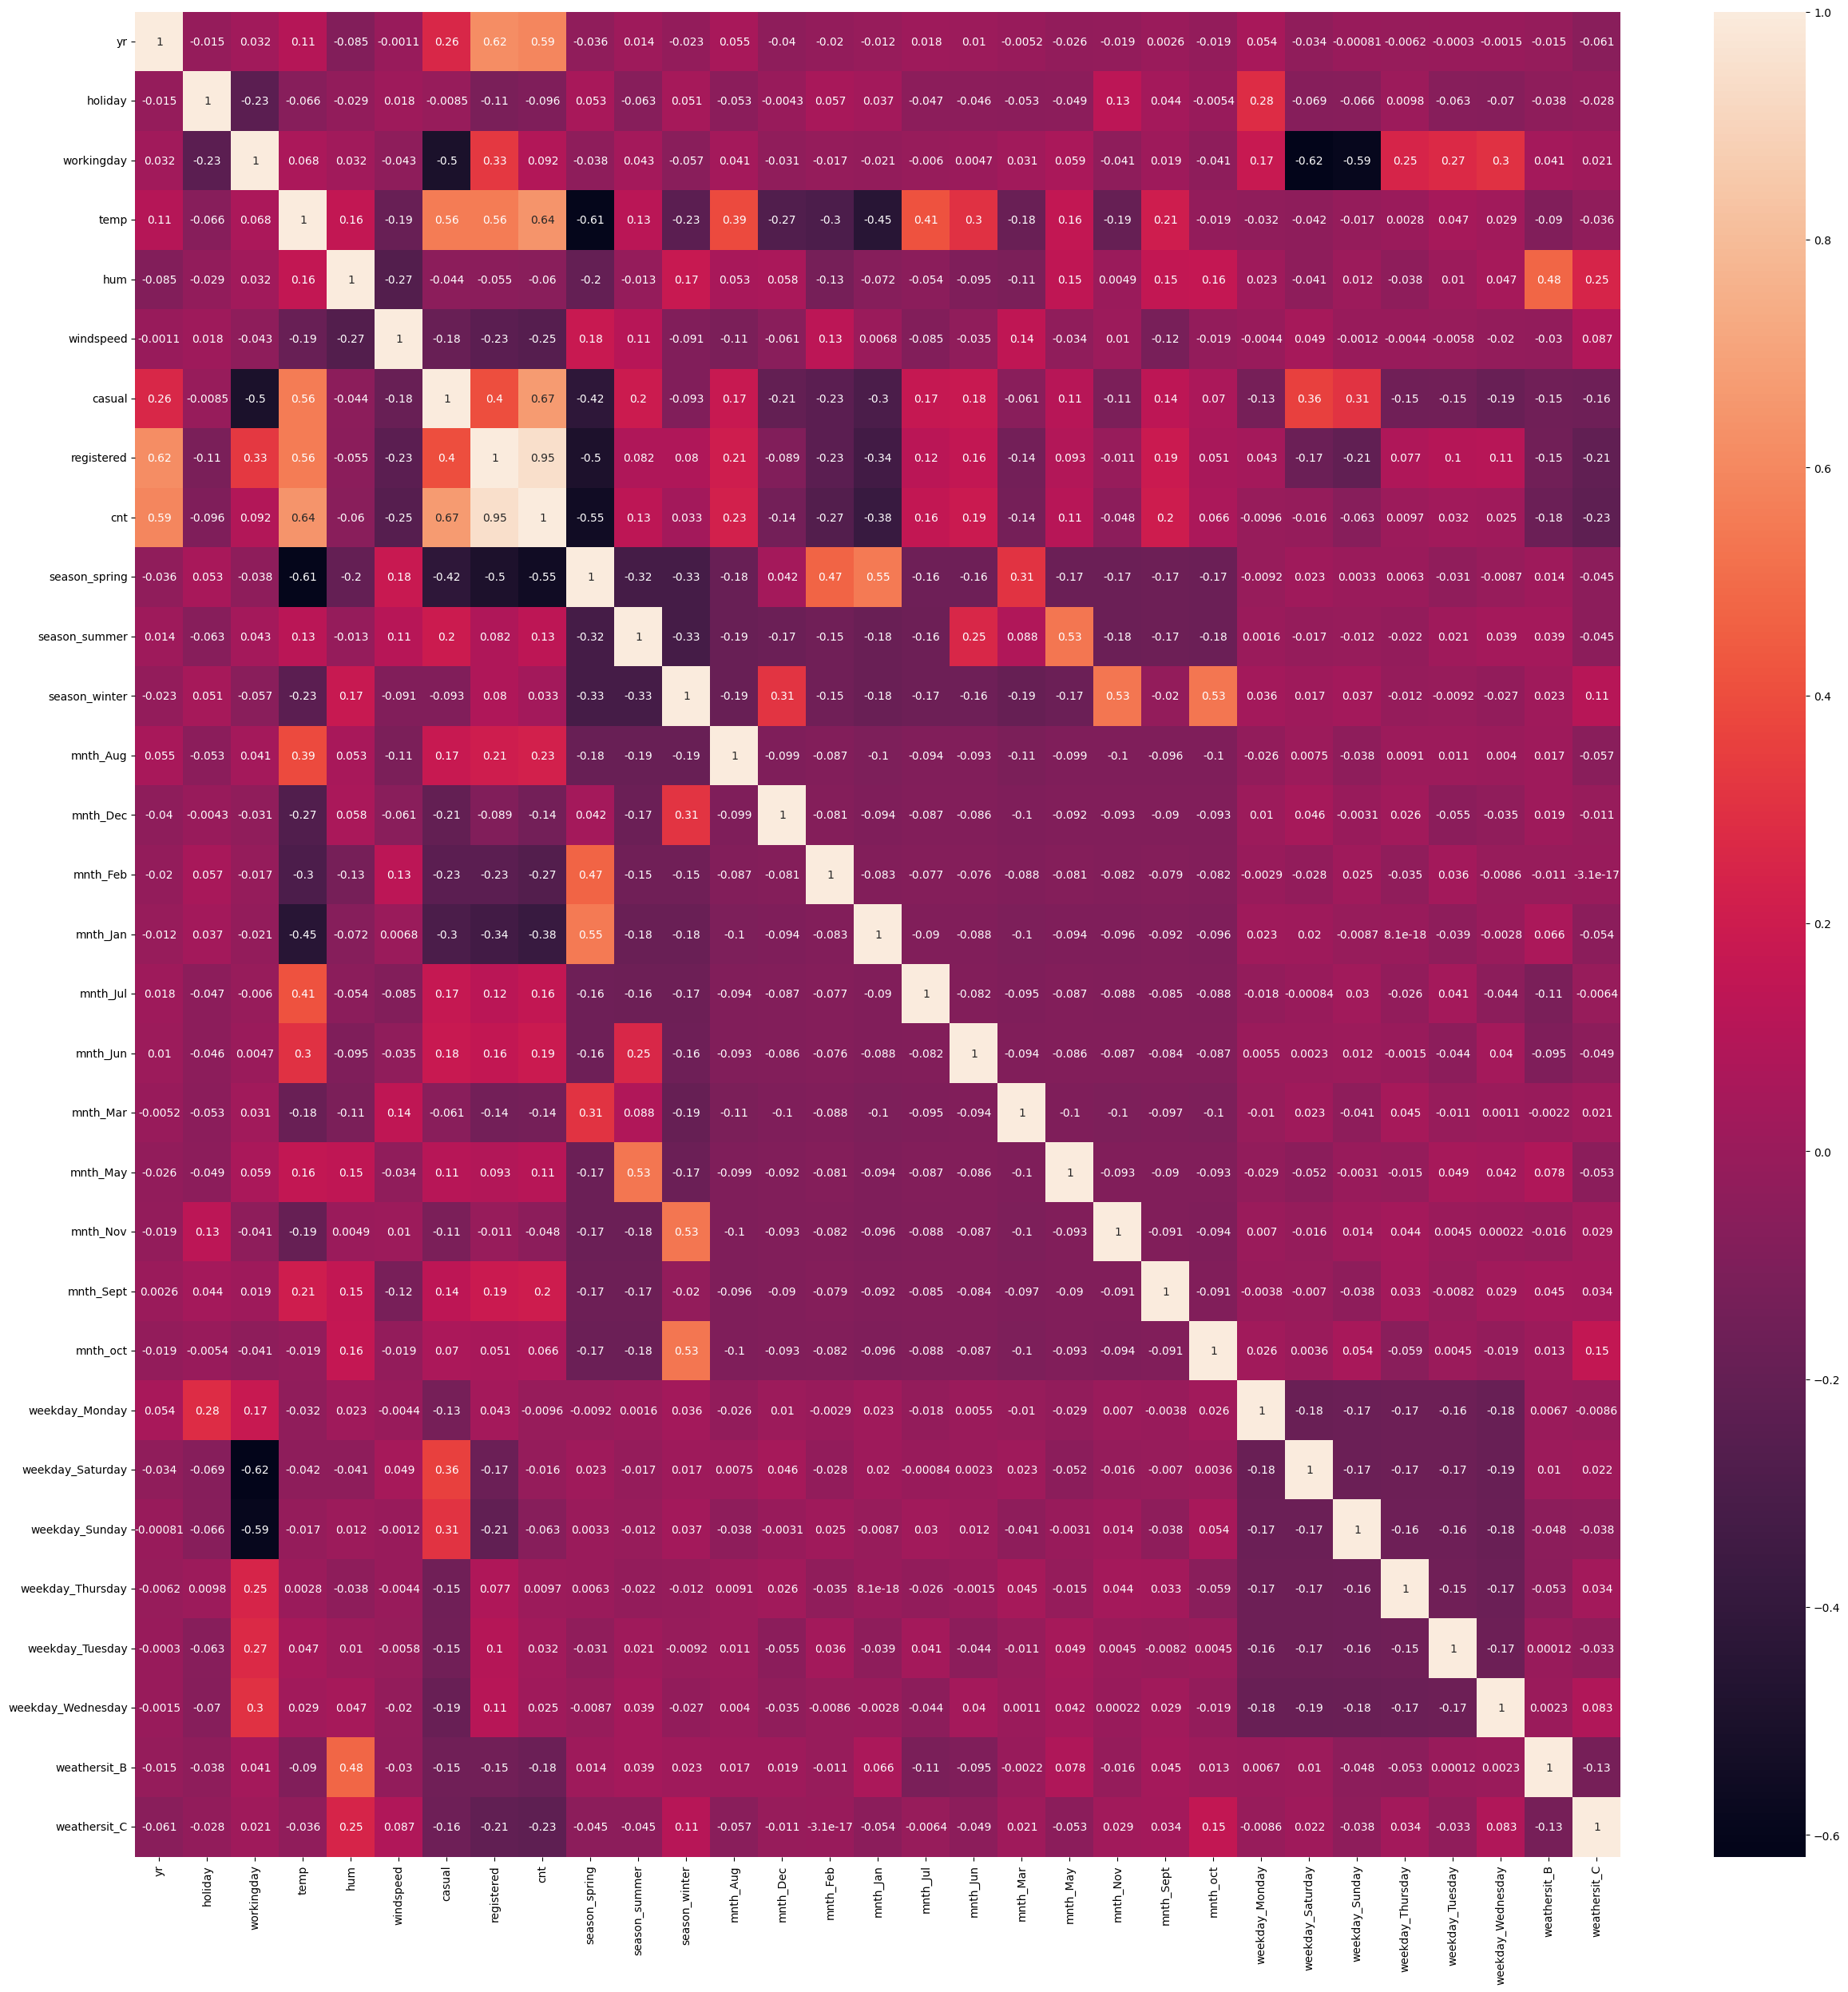

In [58]:
plt.figure(figsize= (30,30))
sns.heatmap(df_train.corr(), annot=True)
plt.show()

In [59]:
y_train = df_train.pop('cnt')
x_train = df_train.drop(["casual", "registered"], axis=1)

In [60]:
x_train.head()

,yr,holiday,workingday,temp,hum,windspeed,season_spring,season_summer,season_winter,mnth_Aug,...,mnth_Sept,mnth_oct,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_B,weathersit_C
653,1,0,1,0.509887,0.575354,0.300794,False,False,True,False,...,False,True,False,False,False,False,True,False,False,False
576,1,0,1,0.815169,0.725633,0.264686,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
426,1,0,0,0.442393,0.640189,0.255342,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
728,1,0,0,0.245101,0.498067,0.663106,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
482,1,0,0,0.395666,0.504508,0.188475,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False


In [61]:
np.asarray(df_train)

array([[1, 0, 1, ..., False, False, False],
       [1, 0, 1, ..., False, False, False],
       [1, 0, 0, ..., False, True, False],
       ...,
       [0, 0, 1, ..., True, False, False],
       [0, 0, 0, ..., False, True, False],
       [0, 0, 1, ..., False, True, False]], dtype=object)

In [62]:
import statsmodels.api as sm
x_train_lm = sm.add_constant(x_train)
x_train_lm = x_train_lm.astype(float)

lr = sm.OLS(y_train, x_train_lm).fit()

In [63]:
x_train_lm

,const,yr,holiday,workingday,temp,hum,windspeed,season_spring,season_summer,season_winter,...,mnth_Sept,mnth_oct,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_B,weathersit_C
653,1.0,1.0,0.0,1.0,0.509887,0.575354,0.300794,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
576,1.0,1.0,0.0,1.0,0.815169,0.725633,0.264686,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
426,1.0,1.0,0.0,0.0,0.442393,0.640189,0.255342,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
728,1.0,1.0,0.0,0.0,0.245101,0.498067,0.663106,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
482,1.0,1.0,0.0,0.0,0.395666,0.504508,0.188475,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,1.0,1.0,0.0,1.0,0.824514,0.605840,0.355596,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
578,1.0,1.0,0.0,1.0,0.863973,0.679690,0.187140,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
53,1.0,0.0,0.0,1.0,0.202618,0.435939,0.111379,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
350,1.0,0.0,0.0,0.0,0.248216,0.577930,0.431816,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [64]:
lr.params

,0
const,0.245085
yr,0.232116
holiday,0.009959
workingday,0.096884
temp,0.450562
hum,-0.151340
windspeed,-0.186453
season_spring,-0.048159
season_summer,0.038725
season_winter,0.105847


In [65]:
lm = LinearRegression()

lm.fit(x_train, y_train)

LinearRegression()

In [66]:
print(lm.coef_)
print(lm.intercept_)

[ 0.23211572 -0.0513123   0.03561284  0.45056169 -0.15134004 -0.18645332
 -0.04815901  0.03872462  0.10584692  0.01440398 -0.0455859  -0.03228181
 -0.06277659 -0.04035007 -0.00297239  0.00104515  0.02393995 -0.04185131
  0.0810599   0.00753359 -0.02090673  0.03511753 -0.01941807 -0.00923674
 -0.01888985 -0.00538751 -0.0610664  -0.25744279]
0.3063556304566333


In [67]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     103.8
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          8.74e-182
Time:                        07:36:58   Log-Likelihood:                 527.95
No. Observations:                 510   AIC:                            -999.9
Df Residuals:                     482   BIC:                            -881.3
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2451      0.035      6.955      0.000       0.176       0.314
yr                    0.2321      0.008     28.820      0.000       0.216       0.248
holiday               0.0100      0.024      0.415      0.678      -0.037       0.057
workingday            0.0969      0.012      7.905      0.000       0.073       0.121
temp                  0.4506      0.046      9.734      0.000       0.360       0.542
hum                  -0.1513      0.038     -3.933      0.000      -0.227      -0.076
windspeed            -0.1865      0.026     -7.257      0.000      -0.237      -0.136
season_spring        -0.0482      0.030     -1.607      0.109      -0.107       0.011
season_summer         0.0387      0.026      1.478      0.140      -0.013       0.090
season_winter         0.1058      0.028      3.794      0.000       0.051       0.161
mnth_Aug              0.0144      0.034      0.428      0.669      -0.052       0.081
mnth_Dec             -0.0456      0.034     -1.358      0.175      -0.112       0.020
mnth_Feb             -0.0323      0.033     -0.982      0.327      -0.097       0.032
mnth_Jan             -0.0628      0.034     -1.873      0.062      -0.129       0.003
mnth_Jul             -0.0404      0.035     -1.151      0.250      -0.109       0.029
mnth_Jun             -0.0030      0.025     -0.119      0.906      -0.052       0.046
mnth_Mar              0.0010      0.025      0.043      0.966      -0.047       0.049
mnth_May              0.0239      0.021      1.140      0.255      -0.017       0.065
mnth_Nov             -0.0419      0.036     -1.152      0.250      -0.113       0.030
mnth_Sept             0.0811      0.032      2.533      0.012       0.018       0.144
mnth_oct              0.0075      0.036      0.211      0.833      -0.063       0.078
weekday_Monday       -0.0209      0.015     -1.366      0.173      -0.051       0.009
weekday_Saturday      0.0964      0.014      7.029      0.000       0.069       0.123
weekday_Sunday        0.0419      0.014      3.006      0.003       0.014       0.069
weekday_Thursday     -0.0092      0.016     -0.595      0.552      -0.040       0.021
weekday_Tuesday      -0.0189      0.015     -1.219      0.223      -0.049       0.012
weekday_Wednesday    -0.0054      0.015     -0.362      0.718      -0.035       0.024
weathersit_B         -0.0611      0.010     -5.854      0.000      -0.082      -0.041
weathersit_C         -0.2574      0.026     -9.778      0.000      -0.309      -0.206
==============================================================================
Omnibus:                       84.475   Durbin-Watson:                   2.040
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              235.382
Skew:                          -0.804   Prob(JB):                     7.72e-52
Kurtosis:      

In [68]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     103.8
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          8.74e-182
Time:                        07:36:58   Log-Likelihood:                 527.95
No. Observations:                 510   AIC:                            -999.9
Df Residuals:                     482   BIC:                            -881.3
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2451      0.035      6.955      0.000       0.176       0.314
yr                    0.2321      0.008     28.820      0.000       0.216       0.248
holiday               0.0100      0.024      0.415      0.678      -0.037       0.057
workingday            0.0969      0.012      7.905      0.000       0.073       0.121
temp                  0.4506      0.046      9.734      0.000       0.360       0.542
hum                  -0.1513      0.038     -3.933      0.000      -0.227      -0.076
windspeed            -0.1865      0.026     -7.257      0.000      -0.237      -0.136
season_spring        -0.0482      0.030     -1.607      0.109      -0.107       0.011
season_summer         0.0387      0.026      1.478      0.140      -0.013       0.090
season_winter         0.1058      0.028      3.794      0.000       0.051       0.161
mnth_Aug              0.0144      0.034      0.428      0.669      -0.052       0.081
mnth_Dec             -0.0456      0.034     -1.358      0.175      -0.112       0.020
mnth_Feb             -0.0323      0.033     -0.982      0.327      -0.097       0.032
mnth_Jan             -0.0628      0.034     -1.873      0.062      -0.129       0.003
mnth_Jul             -0.0404      0.035     -1.151      0.250      -0.109       0.029
mnth_Jun             -0.0030      0.025     -0.119      0.906      -0.052       0.046
mnth_Mar              0.0010      0.025      0.043      0.966      -0.047       0.049
mnth_May              0.0239      0.021      1.140      0.255      -0.017       0.065
mnth_Nov             -0.0419      0.036     -1.152      0.250      -0.113       0.030
mnth_Sept             0.0811      0.032      2.533      0.012       0.018       0.144
mnth_oct              0.0075      0.036      0.211      0.833      -0.063       0.078
weekday_Monday       -0.0209      0.015     -1.366      0.173      -0.051       0.009
weekday_Saturday      0.0964      0.014      7.029      0.000       0.069       0.123
weekday_Sunday        0.0419      0.014      3.006      0.003       0.014       0.069
weekday_Thursday     -0.0092      0.016     -0.595      0.552      -0.040       0.021
weekday_Tuesday      -0.0189      0.015     -1.219      0.223      -0.049       0.012
weekday_Wednesday    -0.0054      0.015     -0.362      0.718      -0.035       0.024
weathersit_B         -0.0611      0.010     -5.854      0.000      -0.082      -0.041
weathersit_C         -0.2574      0.026     -9.778      0.000      -0.309      -0.206
==============================================================================
Omnibus:                       84.475   Durbin-Watson:                   2.040
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              235.382
Skew:                          -0.804   Prob(JB):                     7.72e-52
Kurtosis:      

In [69]:
from sklearn.feature_selection import RFE

In [70]:
lm = LinearRegression()
rfe1 = RFE(lm, n_features_to_select=15)

#fit with 15 feature
rfe1.fit(x_train, y_train)
print(rfe1.support_)
print(rfe1.ranking_)

[ True  True  True  True  True  True  True  True  True False False False
  True  True False False False False  True False False  True False False
 False False  True  True]
[ 1  1  1  1  1  1  1  1  1  6  3  4  1  1 13 14  5  2  1 10  8  1  7 11
  9 12  1  1]


In [71]:
col1 = x_train.columns[rfe1.support_]

In [72]:
col1

Index(['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed',
       'season_spring', 'season_summer', 'season_winter', 'mnth_Jan',
       'mnth_Jul', 'mnth_Sept', 'weekday_Saturday', 'weathersit_B',
       'weathersit_C'],
      dtype='object')

In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [74]:
# Calculate VIF for the selected features
x_train_rfe1 = x_train[col1]

vif = pd.DataFrame()
vif['Features'] = x_train_rfe1.columns
vif['VIF'] = [variance_inflation_factor(x_train_rfe1.values.astype(float), i) for i in range(x_train_rfe1.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
print(vif)

            Features    VIF
4                hum  29.40
3               temp  17.77
2         workingday   5.31
5          windspeed   4.73
6      season_spring   4.53
8      season_winter   3.48
7      season_summer   2.84
13      weathersit_B   2.29
0                 yr   2.09
12  weekday_Saturday   1.98
9           mnth_Jan   1.67
10          mnth_Jul   1.59
11         mnth_Sept   1.39
14      weathersit_C   1.25
1            holiday   1.18


In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

a = x_train_rfe1

a_cleaned = a.dropna()

if a_cleaned.empty:
    print("Warning: All rows contained NaN values after numeric conversion. Cannot calculate VIF.")
else:
    vif = pd.DataFrame()
    vif['Features'] = a_cleaned.columns
    vif['VIF'] = [variance_inflation_factor(a_cleaned.values.astype(float), i) for i in range(a_cleaned.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    print(vif)

            Features    VIF
4                hum  29.40
3               temp  17.77
2         workingday   5.31
5          windspeed   4.73
6      season_spring   4.53
8      season_winter   3.48
7      season_summer   2.84
13      weathersit_B   2.29
0                 yr   2.09
12  weekday_Saturday   1.98
9           mnth_Jan   1.67
10          mnth_Jul   1.59
11         mnth_Sept   1.39
14      weathersit_C   1.25
1            holiday   1.18


In [76]:
lm = LinearRegression()
rfe2 = RFE(lm, n_features_to_select=7) # Pass 7 as a keyword argument

rfe2.fit(x_train, y_train)
print(rfe2.support_)
print(rfe2.ranking_)

[ True False False  True  True  True  True False False False False False
 False  True False False False False False False False False False False
 False False False  True]
[ 1  2  8  1  1  1  1  6  3 14 11 12  9  1 21 22 13 10  4 18 16  7 15 19
 17 20  5  1]


In [77]:
import pandas as pd
import statsmodels.api as sm
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

selected_columns = x_train.columns[rfe2.support_]

x_train_rfe2 = x_train[selected_columns]

x_train_rfe2_const = sm.add_constant(x_train_rfe2)

x_train_rfe2_const = x_train_rfe2_const.astype(float)
lm2 = sm.OLS(y_train, x_train_rfe2_const).fit()

print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     312.2
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.34e-178
Time:                        07:36:59   Log-Likelihood:                 466.35
No. Observations:                 510   AIC:                            -916.7
Df Residuals:                     502   BIC:                            -882.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4277      0.030     14.348

In [78]:
# Calculate VIF for the selected features after the second RFE iteration
b = x_train_rfe2
vif1 = pd.DataFrame()
vif1['Features'] = b.columns
vif1['VIF'] = [variance_inflation_factor(b.values.astype(float), i) for i in range(b.shape[1])]
vif1['VIF'] = round(vif1['VIF'], 2)
vif1 = vif1.sort_values(by = "VIF", ascending = False)
print(vif1)

        Features    VIF
2            hum  10.47
1           temp  10.37
3      windspeed   3.89
0             yr   2.03
4  season_spring   1.80
5       mnth_Jul   1.35
6   weathersit_C   1.11


In [79]:
y_train_cmt = lm2.predict(sm.add_constant(x_train_rfe2, has_constant='add'))

<Axes: ylabel='Density'>

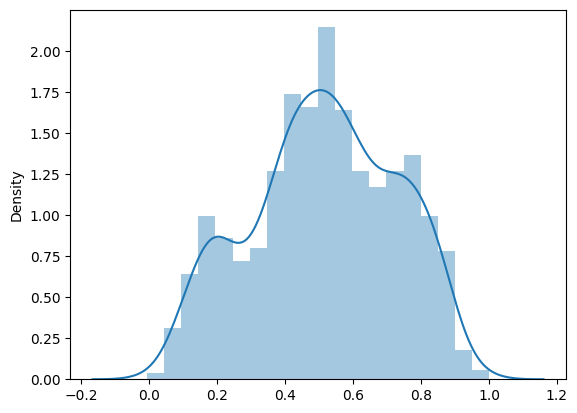

In [80]:
fig = plt.figure()
sns.distplot((y_train, y_train_cmt), bins=20)

In [81]:
df_test[var] = scaler.transform(df_test[var])
df_test

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,season_spring,...,mnth_Sept,mnth_oct,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_B,weathersit_C
184,0,1,0,0.831783,0.657364,0.084219,0.933557,0.427086,0.692706,False,...,False,False,True,False,False,False,False,False,True,False
535,1,0,1,0.901354,0.610133,0.153728,0.265163,0.767976,0.712034,False,...,False,False,False,False,False,False,False,True,False,False
299,0,0,1,0.511964,0.837699,0.334206,0.072539,0.346376,0.303382,False,...,False,True,False,False,False,True,False,False,True,False
221,0,0,1,0.881625,0.437098,0.339570,0.268820,0.559630,0.547400,False,...,False,False,False,False,False,False,False,True,False,False
152,0,0,1,0.817246,0.314298,0.537414,0.223712,0.608143,0.569029,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,1,0,0,0.257562,0.708888,0.287411,0.096312,0.376697,0.336516,True,...,False,False,False,False,True,False,False,False,True,False
702,1,0,1,0.519232,0.756118,0.283397,0.167327,0.871354,0.757478,False,...,False,False,False,False,False,False,True,False,False,False
127,0,0,0,0.584649,0.650923,0.069510,0.426394,0.420445,0.495973,False,...,False,False,False,False,True,False,False,False,False,False
640,1,0,1,0.745598,0.817947,0.052115,0.221274,0.985273,0.868615,False,...,False,True,False,False,False,False,False,True,True,False


In [82]:
y_test = df_test.pop('cnt')
x_test = df_test.drop(["casual", "registered"], axis=1)

In [83]:
x_test.head()

,yr,holiday,workingday,temp,hum,windspeed,season_spring,season_summer,season_winter,mnth_Aug,...,mnth_Sept,mnth_oct,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_B,weathersit_C
184,0,1,0,0.831783,0.657364,0.084219,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
535,1,0,1,0.901354,0.610133,0.153728,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
299,0,0,1,0.511964,0.837699,0.334206,False,False,True,False,...,False,True,False,False,False,True,False,False,True,False
221,0,0,1,0.881625,0.437098,0.339570,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
152,0,0,1,0.817246,0.314298,0.537414,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False


In [84]:
col2 = x_train_rfe2.columns

In [85]:
x_test_rfe2 = x_test[col2]

In [86]:
x_test_rfe2 = sm.add_constant(x_test_rfe2)

In [87]:
x_test_rfe2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 184 to 72
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   const          219 non-null    float64
 1   yr             219 non-null    int64  
 2   temp           219 non-null    float64
 3   hum            219 non-null    float64
 4   windspeed      219 non-null    float64
 5   season_spring  219 non-null    bool   
 6   mnth_Jul       219 non-null    bool   
 7   weathersit_C   219 non-null    bool   
dtypes: bool(3), float64(4), int64(1)
memory usage: 10.9 KB


In [88]:
y_pred = lm2.predict(x_test_rfe2)

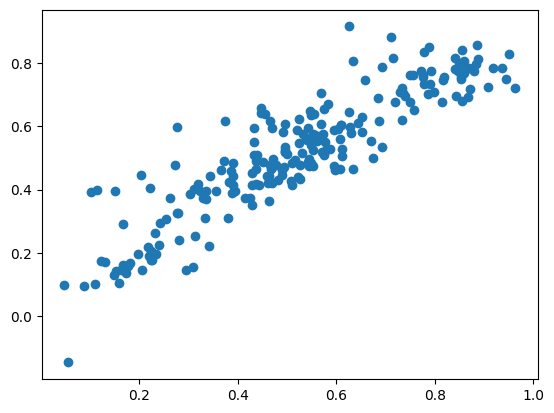

In [89]:
plt.figure()
plt.scatter(y_test, y_pred)

In [90]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = math.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

results_lr = pd.DataFrame({
    "Model": ["Linear Regression"],
    "R2": [round(r2_lr, 4)],
    "MSE": [round(mse_lr, 4)],
    "RMSE": [round(rmse_lr, 4)],
    "MAE": [round(mae_lr, 4)]
})
print("Linear Regression Performance:")
display(results_lr)

Linear Regression Performance:


,Model,R2,MSE,RMSE,MAE
0,Linear Regression,0.8052,0.0093,0.0962,0.0726


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['R2', 'MSE', 'RMSE', 'MAE']
values = [r2_lr, mse_lr, rmse_lr, mae_lr]

sns.set(style="whitegrid", palette="pastel")

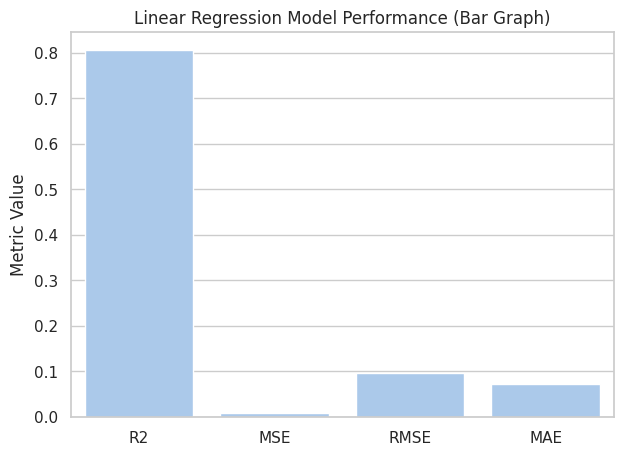

In [92]:
# Bar Graph
plt.figure(figsize=(7, 5))
sns.barplot(x=metrics, y=values)
plt.title("Linear Regression Model Performance (Bar Graph)")
plt.ylabel("Metric Value")
plt.show()

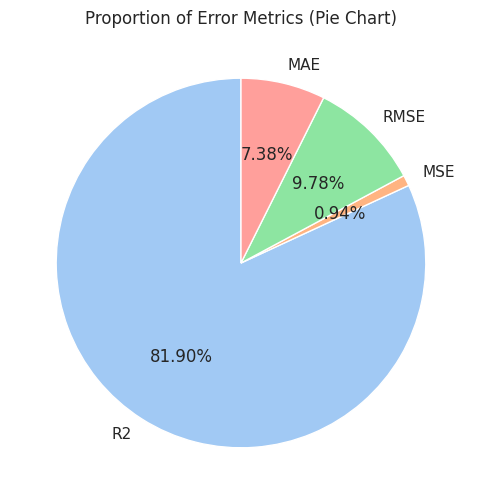

In [93]:
# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(values, labels=metrics, autopct='%1.2f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Proportion of Error Metrics (Pie Chart)")
plt.show()

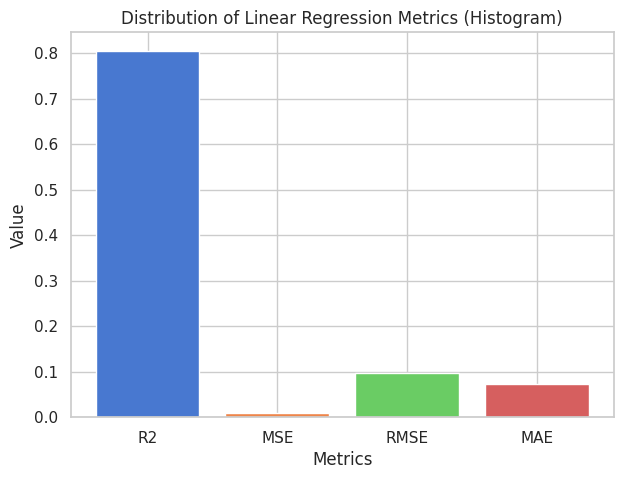

In [94]:
#Histogram
plt.figure(figsize=(7, 5))
plt.bar(metrics, values, color=sns.color_palette("muted"))
plt.title("Distribution of Linear Regression Metrics (Histogram)")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.show()

**================= Decision Tree =================**

In [95]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

In [96]:
# Prepare training and test data (same columns as used in lm2)
X_train = x_train_rfe2.astype(float)
X_test = x_test_rfe2.astype(float)

In [97]:
# Train Decision Tree
dt_model = DecisionTreeRegressor(random_state=42, max_depth=6)  # you can tune max_depth
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6, random_state=42)

In [98]:
# Predictions
y_pred_dt = dt_model.predict(X_test.drop('const', axis=1))

In [99]:
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred_dt)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

In [100]:
results_dt = pd.DataFrame({
    "Model": ["Decision Tree"],
    "R2": [round(r2, 4)],
    "MSE": [round(mse, 4)],
    "RMSE": [round(rmse, 4)],
    "MAE": [round(mae, 4)]
})

print("Decision Tree Performance:")
display(results_dt)

Decision Tree Performance:


,Model,R2,MSE,RMSE,MAE
0,Decision Tree,0.7987,0.0096,0.0978,0.0742


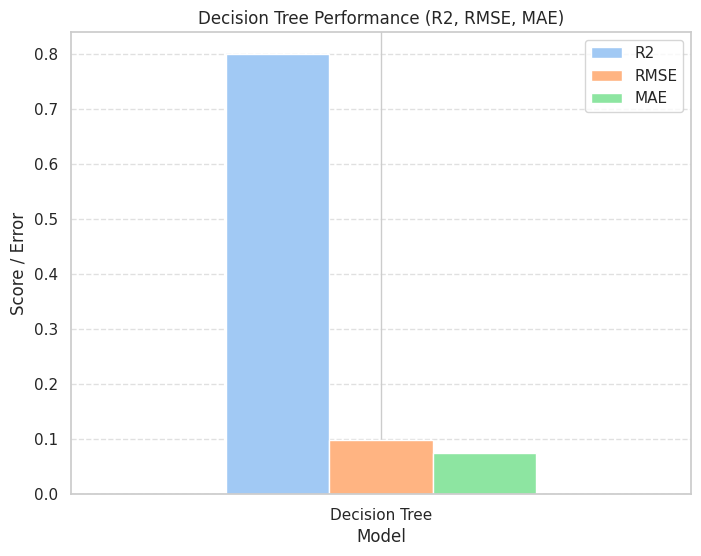

In [101]:
# 1. Bar Chart of Metrics
results_dt.set_index("Model")[["R2", "RMSE", "MAE"]].plot(kind="bar", figsize=(8,6))
plt.title("Decision Tree Performance (R2, RMSE, MAE)")
plt.ylabel("Score / Error")
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.show()

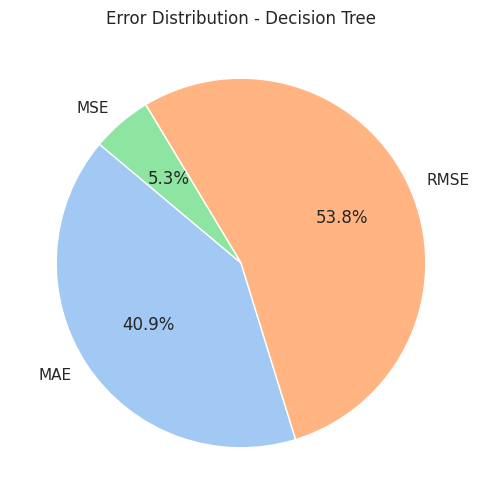

In [102]:
# 2. Pie Chart of error contribution (MAE, RMSE, MSE relative)
error_vals = [mae, rmse, mse]
error_labels = ["MAE", "RMSE", "MSE"]

plt.figure(figsize=(6,6))
plt.pie(error_vals, labels=error_labels, autopct='%1.1f%%', startangle=140)
plt.title("Error Distribution - Decision Tree")
plt.show()

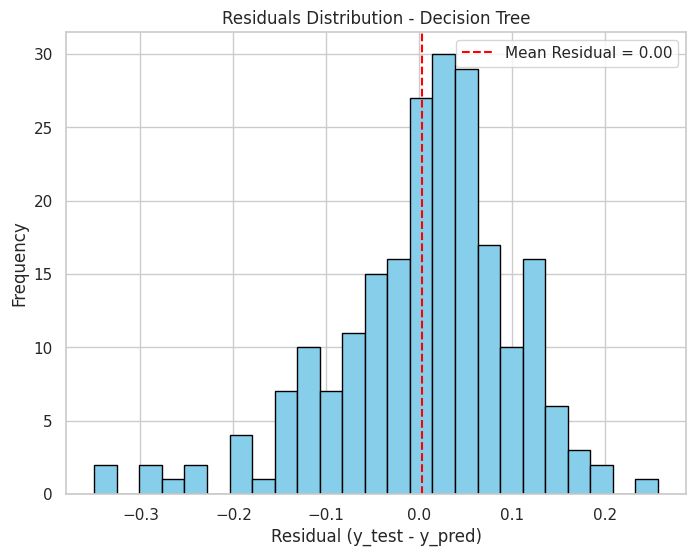

In [103]:
# 3. Histogram of residuals
residuals = y_test - y_pred_dt
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=25, color="skyblue", edgecolor="black")
plt.axvline(residuals.mean(), color="red", linestyle="--", label=f"Mean Residual = {residuals.mean():.2f}")
plt.title("Residuals Distribution - Decision Tree")
plt.xlabel("Residual (y_test - y_pred)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**================= Random Forest Model =================**

In [104]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

In [105]:
# Prepare training and test data (same as before)
X_train = x_train_rfe2.astype(float)
X_test = x_test_rfe2.drop('const', axis=1).astype(float)

In [106]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [107]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

In [108]:
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred_rf)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

In [109]:
# Store results in DataFrame
results_rf = pd.DataFrame({
    "Model": ["Random Forest"],
    "R2": [round(r2, 4)],
    "MSE": [round(mse, 4)],
    "RMSE": [round(rmse, 4)],
    "MAE": [round(mae, 4)]
})

print("Random Forest Performance:")
display(results_rf)

Random Forest Performance:


,Model,R2,MSE,RMSE,MAE
0,Random Forest,0.8594,0.0067,0.0817,0.0615


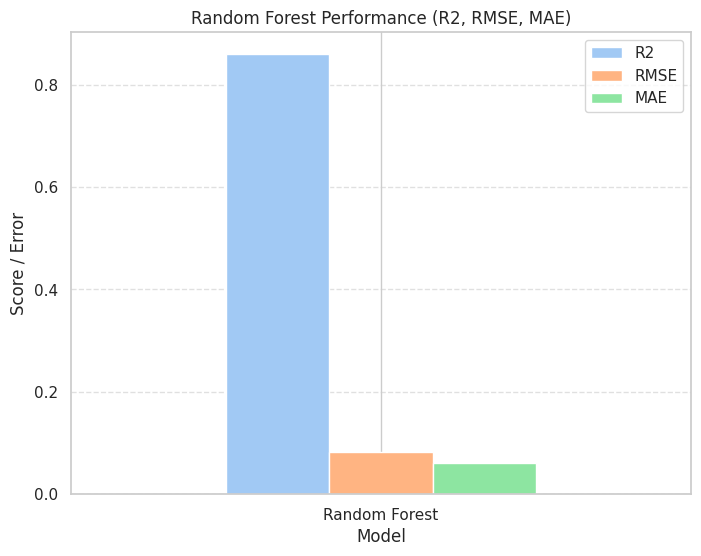

In [110]:
# 1. Bar Chart of Metrics
results_rf.set_index("Model")[["R2", "RMSE", "MAE"]].plot(kind="bar", figsize=(8,6))
plt.title("Random Forest Performance (R2, RMSE, MAE)")
plt.ylabel("Score / Error")
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.show()

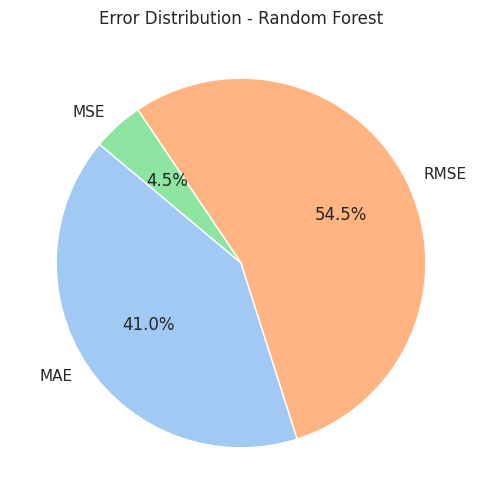

In [111]:
error_vals = [mae, rmse, mse]
error_labels = ["MAE", "RMSE", "MSE"]

plt.figure(figsize=(6,6))
plt.pie(error_vals, labels=error_labels, autopct='%1.1f%%', startangle=140)
plt.title("Error Distribution - Random Forest")
plt.show()

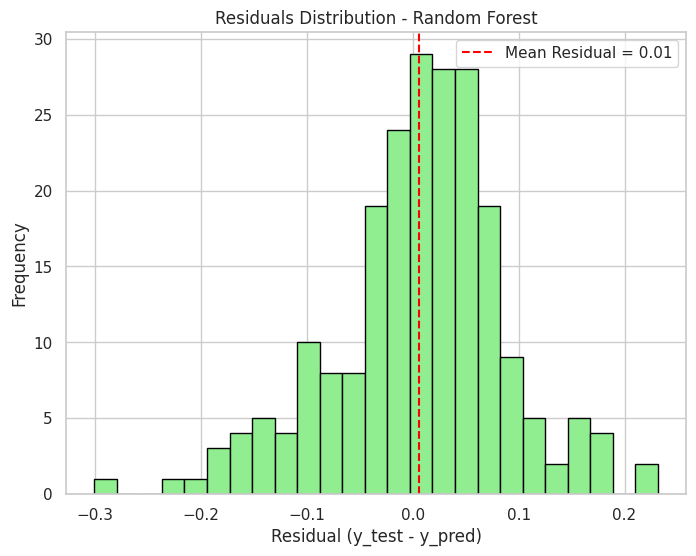

In [112]:
# 3. Histogram of residuals
residuals = y_test - y_pred_rf
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=25, color="lightgreen", edgecolor="black")
plt.axvline(residuals.mean(), color="red", linestyle="--", label=f"Mean Residual = {residuals.mean():.2f}")
plt.title("Residuals Distribution - Random Forest")
plt.xlabel("Residual (y_test - y_pred)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**================= SVM Model =================**

In [113]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

In [114]:
# Prepare training and test data (same as before)
X_train = x_train_rfe2.astype(float)
X_test = x_test_rfe2.drop('const', axis=1).astype(float)

In [115]:
# Train SVM (Support Vector Regressor)
svm_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)  # parameters can be tuned
svm_model.fit(X_train, y_train)

SVR(C=100, gamma=0.1)

In [116]:
# Predictions
y_pred_svm = svm_model.predict(X_test)

In [117]:
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred_svm)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_svm)
r2 = r2_score(y_test, y_pred_svm)

In [118]:
# Store results in DataFrame
results_svm = pd.DataFrame({
    "Model": ["SVM (SVR)"],
    "R2": [round(r2, 4)],
    "MSE": [round(mse, 4)],
    "RMSE": [round(rmse, 4)],
    "MAE": [round(mae, 4)]
})

print("SVM (SVR) Performance:")
display(results_svm)

SVM (SVR) Performance:


,Model,R2,MSE,RMSE,MAE
0,SVM (SVR),0.8748,0.0059,0.0771,0.0586


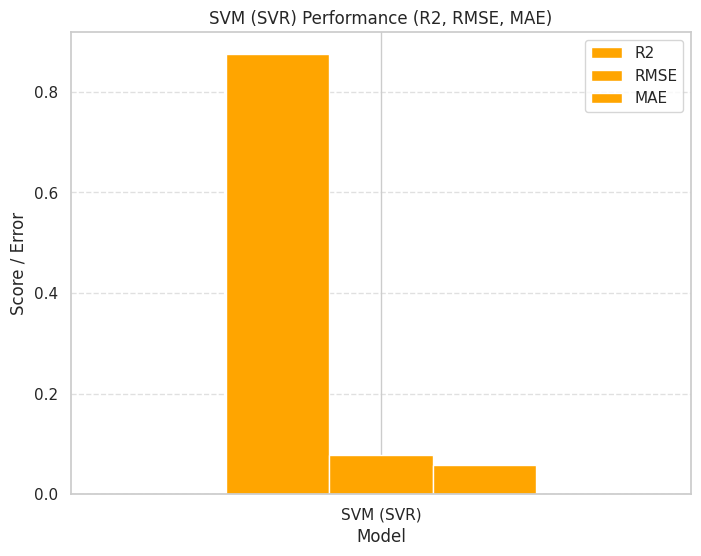

In [119]:
# 1. Bar Chart of Metrics
results_svm.set_index("Model")[["R2", "RMSE", "MAE"]].plot(kind="bar", figsize=(8,6), color="orange")
plt.title("SVM (SVR) Performance (R2, RMSE, MAE)")
plt.ylabel("Score / Error")
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.show()

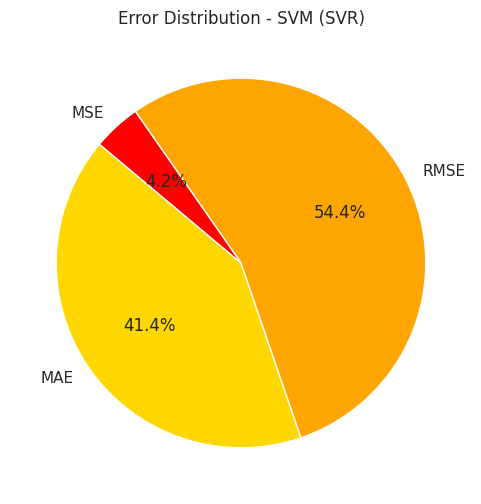

In [120]:
# 2. Pie Chart of error contribution (MAE, RMSE, MSE relative)
error_vals = [mae, rmse, mse]
error_labels = ["MAE", "RMSE", "MSE"]

plt.figure(figsize=(6,6))
plt.pie(error_vals, labels=error_labels, autopct='%1.1f%%', startangle=140, colors=["gold","orange","red"])
plt.title("Error Distribution - SVM (SVR)")
plt.show()

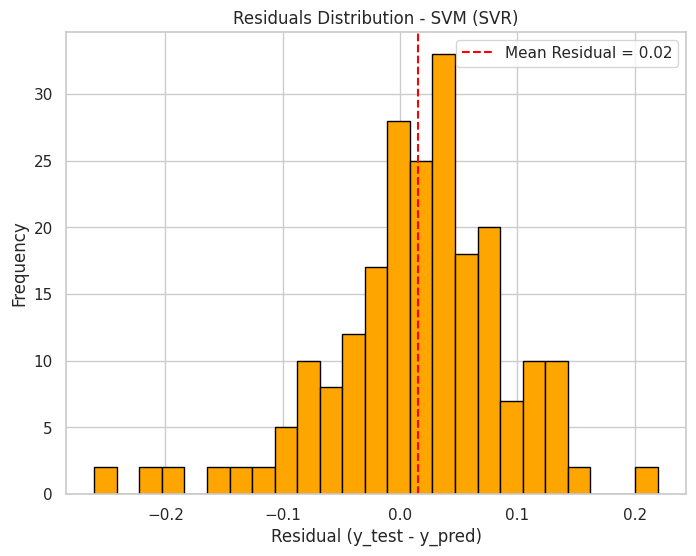

In [121]:
# 3. Histogram of residuals
residuals = y_test - y_pred_svm
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=25, color="orange", edgecolor="black")
plt.axvline(residuals.mean(), color="red", linestyle="--", label=f"Mean Residual = {residuals.mean():.2f}")
plt.title("Residuals Distribution - SVM (SVR)")
plt.xlabel("Residual (y_test - y_pred)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**================= AdaBoost Model =================**

In [122]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

In [123]:
# Prepare training and test data (same as before)
X_train = x_train_rfe2.astype(float)
X_test = x_test_rfe2.drop('const', axis=1).astype(float)

In [124]:
# Train AdaBoost Regressor
ada_model = AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
ada_model.fit(X_train, y_train)

AdaBoostRegressor(learning_rate=0.1, n_estimators=200, random_state=42)

In [125]:
# Predictions
y_pred_ada = ada_model.predict(X_test)

In [126]:
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred_ada)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_ada)
r2 = r2_score(y_test, y_pred_ada)

In [127]:
results_ada = pd.DataFrame({
    "Model": ["AdaBoost"],
    "R2": [round(r2, 4)],
    "MSE": [round(mse, 4)],
    "RMSE": [round(rmse, 4)],
    "MAE": [round(mae, 4)]
})

print("AdaBoost Performance:")
display(results_ada)

AdaBoost Performance:


,Model,R2,MSE,RMSE,MAE
0,AdaBoost,0.7804,0.0104,0.1021,0.0787


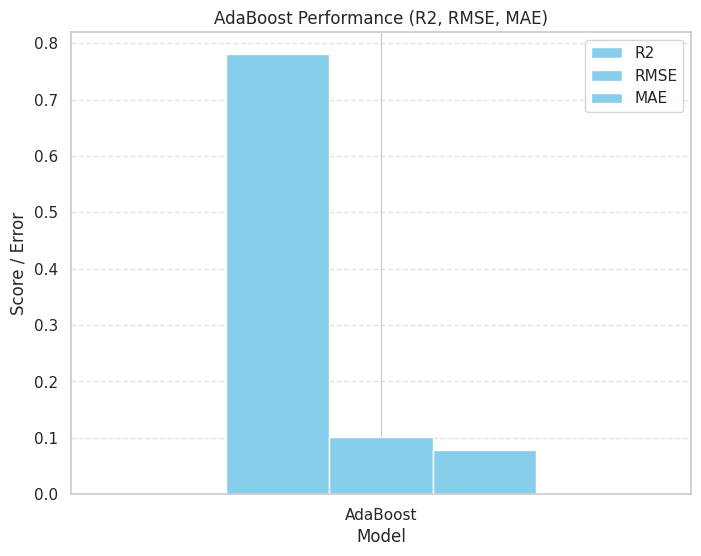

In [128]:
# 1. Bar Chart of Metrics
results_ada.set_index("Model")[["R2", "RMSE", "MAE"]].plot(kind="bar", figsize=(8,6), color="skyblue")
plt.title("AdaBoost Performance (R2, RMSE, MAE)")
plt.ylabel("Score / Error")
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.show()

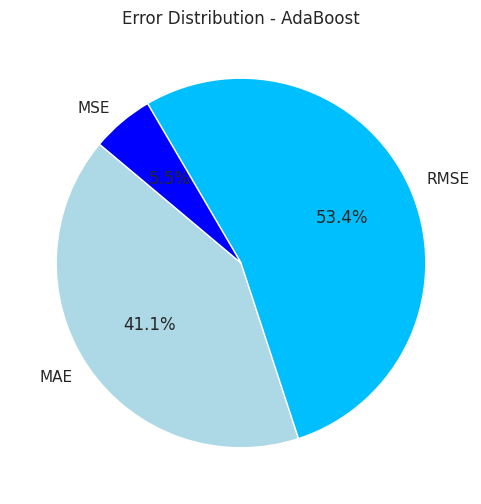

In [129]:
# 2. Pie Chart of error contribution (MAE, RMSE, MSE relative)
error_vals = [mae, rmse, mse]
error_labels = ["MAE", "RMSE", "MSE"]

plt.figure(figsize=(6,6))
plt.pie(error_vals, labels=error_labels, autopct='%1.1f%%', startangle=140, colors=["lightblue","deepskyblue","blue"])
plt.title("Error Distribution - AdaBoost")
plt.show()

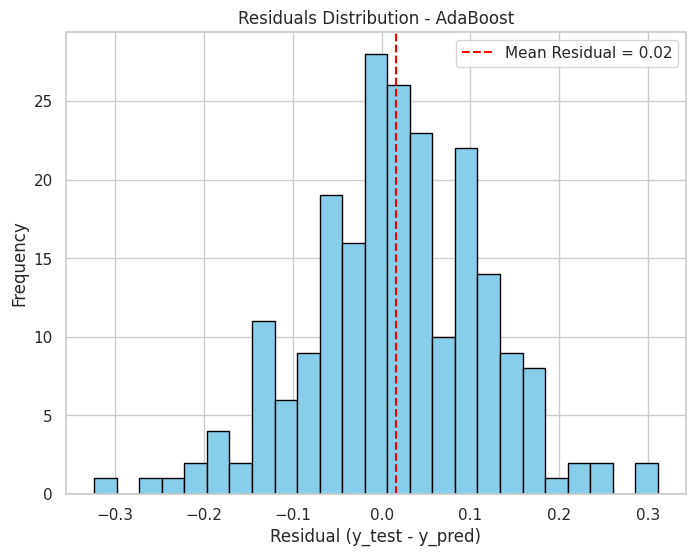

In [130]:
# 3. Histogram of residuals
residuals = y_test - y_pred_ada
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=25, color="skyblue", edgecolor="black")
plt.axvline(residuals.mean(), color="red", linestyle="--", label=f"Mean Residual = {residuals.mean():.2f}")
plt.title("Residuals Distribution - AdaBoost")
plt.xlabel("Residual (y_test - y_pred)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [131]:
final_results = pd.concat([results_dt, results_rf, results_svm, results_ada], ignore_index=True)
display(final_results)

,Model,R2,MSE,RMSE,MAE
0,Decision Tree,0.7987,0.0096,0.0978,0.0742
1,Random Forest,0.8594,0.0067,0.0817,0.0615
2,SVM (SVR),0.8748,0.0059,0.0771,0.0586
3,AdaBoost,0.7804,0.0104,0.1021,0.0787


In [132]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = math.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)
accuracy_lr = round(r2_lr * 100, 2)

results_lr = pd.DataFrame({
    "Model": ["Linear Regression"],
    "R2": [round(r2_lr, 4)],
    "MSE": [round(mse_lr, 4)],
    "RMSE": [round(rmse_lr, 4)],
    "MAE": [round(mae_lr, 4)],
    "Accuracy (%)": [accuracy_lr]
})


In [133]:
def add_accuracy_column(df):
    df = df.copy()
    df["Accuracy (%)"] = round(df["R2"] * 100, 2)
    return df

results_dt_acc = add_accuracy_column(results_dt)
results_rf_acc = add_accuracy_column(results_rf)
results_svm_acc = add_accuracy_column(results_svm)
results_ada_acc = add_accuracy_column(results_ada)

# 3. Combine all results
final_results = pd.concat([
    results_lr,
    results_dt_acc,
    results_rf_acc,
    results_svm_acc,
    results_ada_acc

], ignore_index=True)

# 4. Display final summary table
print("Final Model Evaluation Metrics with Accuracy:")
display(final_results)


Final Model Evaluation Metrics with Accuracy:


,Model,R2,MSE,RMSE,MAE,Accuracy (%)
0,Linear Regression,0.8052,0.0093,0.0962,0.0726,80.52
1,Decision Tree,0.7987,0.0096,0.0978,0.0742,79.87
2,Random Forest,0.8594,0.0067,0.0817,0.0615,85.94
3,SVM (SVR),0.8748,0.0059,0.0771,0.0586,87.48
4,AdaBoost,0.7804,0.0104,0.1021,0.0787,78.04
